
# 7.9: Optimize simulated evoked response parameters

This example demonstrates how to optimize the parameters
of the model simulation to match an experimental dipole waveform.


Authors: 

- Carolina Fernandez ( cxf418@miami.edu )
- Nick Tolley ( nicholas_tolley@brown.edu )
- Ryan Thorpe ( ryan_thorpe@brown.edu )
- Mainak Jas ( mjas@mgh.harvard.edu )

## 1. Import Optimization dependencies

**Please note that in order to run this tutorial you MUST have installed the optimization dependencies for HNN-Core. Normally, these are optional for general HNN-Core use, but they are required for this tutorial. In the next cell, we will check to make sure they are installed, and if they are not, then please follow the directions provided.**


In [2]:
try:
    from hnn_core.optimization import Optimizer
except ImportError:
    raise ImportError("""
The optimization module is not available. Please install the hnn-core package using

    pip install "hnn-core[opt]"

""")

--No graphics will be displayed.


If you installed `hnn_core` using the Python or Conda package (i.e. not from source), then you can **uncomment and run** the following code cell to easily install the optimization dependences into your current Python environment. If you do so, please restart your Jupyter kernel before running the notebook again.

In [3]:
# %pip install -q "hnn-core[opt]"

## 2. Import remaining libraries

Next, let's import the other `hnn_core` modules and external libraries required for this tutorial. Note: it is strongly recommended that you [follow the "MPI Installation" sections of our Installation Guide](https://jonescompneurolab.github.io/textbook/content/01_getting_started/installation.html) if you want to run this tutorial or use Optimization in HNN-Core, since doing so will GREATLY speed up how fast the optimization runs. Optimization is a very compute-heavy operation, and in typical scientific use, MPI can speed up an optimization that would take days into taking only hours to run. If you need help with installation (including MPI), then please reach out on our [Discussion Board](https://github.com/jonescompneurolab/hnn-core/discussions).

In [ ]:
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from hnn_core import jones_2009_model, simulate_dipole, read_dipole
from hnn_core.viz import plot_dipole

# --- Parallel backend ---
# HNN-Core's "MPIBackend" gives the largest speed-up, but requires both the `mpi4py`
# Python package and an MPI installation. If either is missing, we fall back to Joblib,
# which parallelizes *across* trials only, and therefore does not speed up any
# single-trial simulations.
#
# We offer complete guides to installing MPI with HNN-Core at
# https://jonescompneurolab.github.io/textbook/content/01_getting_started/installation.html
# and if you have any installation issues, feel free to reach out to us on our
# Discussion Board at https://github.com/jonescompneurolab/hnn-core/discussions where we
# can help you troubleshoot.
try:
    import mpi4py  # noqa: F401
    import psutil
    n_procs = psutil.cpu_count(logical=False)
    use_mpi = True
    print('Using MPIBackend with %d processes' % n_procs)
    from hnn_core.parallel_backends import MPIBackend
except ImportError:
    n_procs = 1
    use_mpi = False
    print('MPI is not available; using JoblibBackend instead')
    from hnn_core.parallel_backends import JoblibBackend

backend = MPIBackend(n_procs=n_procs) if use_mpi else JoblibBackend(n_jobs=1)

Using MPIBackend with 12 processes


/opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/parallel_backends.py:897: UserWarning: Number of requested MPI processes exceeds available cores. Enabling MPI oversubscription automatically.
  warn(


## 3. Load experimental dipole

Our goal is to optimize our model to match experimental data.

We'll load a pre-recorded MEG dipole waveform, which represents early evoked
activity from primary somatosensory cortex in response to a brief tap to
the finger. This data will serve as our *target dipole* for the optimization
process.



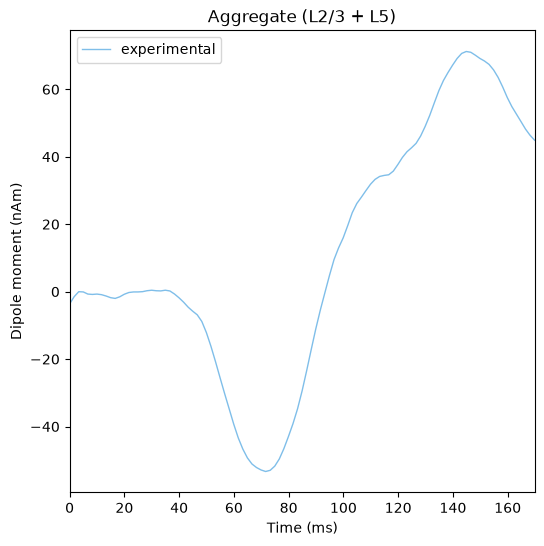

In [5]:
data_url = ('https://raw.githubusercontent.com/jonescompneurolab/hnn/master/'
            'data/MEG_detection_data/yes_trial_S1_ERP_all_avg.txt')
urlretrieve(data_url, 'yes_trial_S1_ERP_all_avg.txt')
dipole_experimental = read_dipole('yes_trial_S1_ERP_all_avg.txt')

# Plot
fig, ax = plt.subplots(figsize=(6, 6))
dipole_experimental.plot(ax=ax, layer='agg', show=False,
                         color='tab:blue')
ax.legend(['experimental'])

## 4. Simulate initial dipole

Now, we'll simulate the initial dipole using a predefined set of parameters
we arrived to after some hand-tuning. This simulation will provide a baseline
to compare against the experimental data before optimization.



MPI will run 3 trial(s) sequentially by distributing network neurons over 12 processes.
numprocs=12
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from 

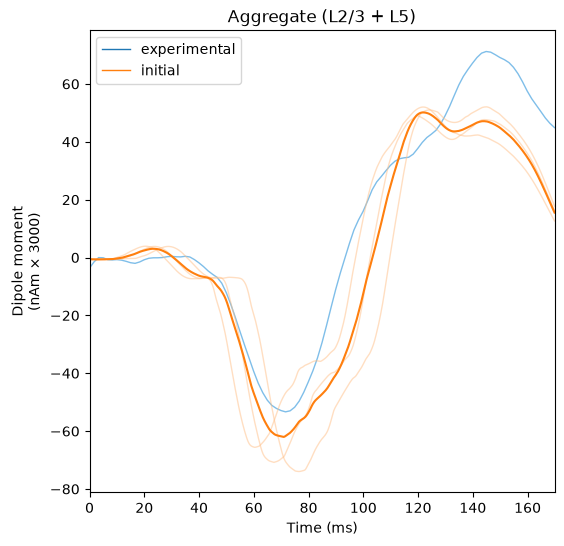

In [6]:
net_initial = jones_2009_model()

n_drive_cells = 1
cell_specific = False

# Proximal 1
weights_ampa_p1 = {'L2_basket': 0.08831, 'L2_pyramidal': 0.01525,
                   'L5_basket': 0.19934, 'L5_pyramidal': 0.00865}
synaptic_delays_p = {'L2_basket': 0.1, 'L2_pyramidal': 0.1,
                     'L5_basket': 1., 'L5_pyramidal': 1.}
net_initial.add_evoked_drive('evprox1',
                             mu=26.61,
                             sigma=2.47,
                             numspikes=1,
                             location='proximal',
                             weights_ampa=weights_ampa_p1,
                             synaptic_delays=synaptic_delays_p,
                             n_drive_cells=n_drive_cells,
                             cell_specific=cell_specific)

# Distal
weights_ampa_d1 = {'L2_basket': 0.006562, 'L2_pyramidal': .000007,
                   'L5_pyramidal': 0.142300}
weights_nmda_d1 = {'L2_basket': 0.019482, 'L2_pyramidal': 0.004317,
                   'L5_pyramidal': 0.080074}
synaptic_delays_d1 = {'L2_basket': 0.1, 'L2_pyramidal': 0.1,
                      'L5_pyramidal': 0.1}
net_initial.add_evoked_drive('evdist1',
                             mu=63.53,
                             sigma=3.85,
                             numspikes=1,
                             location='distal',
                             weights_ampa=weights_ampa_d1,
                             weights_nmda=weights_nmda_d1,
                             synaptic_delays=synaptic_delays_d1,
                             n_drive_cells=n_drive_cells,
                             cell_specific=cell_specific)

# Proximal 2
weights_ampa_p2 = {'L2_basket': 0.000003, 'L2_pyramidal': 1.438840,
                   'L5_basket': 0.008958, 'L5_pyramidal': 0.1}
net_initial.add_evoked_drive('evprox2',
                             mu=120.,
                             sigma=1.,
                             numspikes=1,
                             location='proximal',
                             weights_ampa=weights_ampa_p2,
                             synaptic_delays=synaptic_delays_p,
                             n_drive_cells=n_drive_cells,
                             cell_specific=cell_specific)

# Simulate initial dipole
n_trials = 3
tstop = dipole_experimental.times[-1]
with backend:
    dipoles_initial = simulate_dipole(
        net_initial, tstop=tstop, n_trials=n_trials)

# Smooth and scale
window_length = 30
scaling_factor = 3000
for dipole in dipoles_initial:
    dipole.smooth(window_length).scale(scaling_factor)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))
dipole_experimental.plot(ax=ax, layer='agg', show=False,
                         color='tab:blue')
plot_dipole(dipoles_initial.copy(), ax=ax, layer='agg', show=False,
            color='tab:orange', average=True)

# Legend
legend_handles = [Line2D([0], [0], color='tab:blue', lw=1.0),
                  Line2D([0], [0], color='tab:orange', lw=1.0)]
ax.legend(legend_handles, ['experimental', 'initial'])

## 5. Define the `set_params` function

Now we can begin the optimization!

First, we'll define a `set_params` function. This function tells the optimizer
how to apply the chosen parameters to the network during each iteration.

Comparison of the initial dipoles reveals that the second positive peak of the
experimental dipole (blue) has a larger amplitude, later latency, and broader
temporal distribution than the corresponding peak in the initial dipole (orange).

Let's optimize the relevant parameters for the second proximal (`evprox2`) drive,
as it is primarily responsible for this component of the dipole.



In [7]:
def set_params(net, params):

    # Proximal 1
    net.add_evoked_drive('evprox1',
                         mu=26.61,
                         sigma=2.47,
                         numspikes=1,
                         location='proximal',
                         weights_ampa=weights_ampa_p1,
                         synaptic_delays=synaptic_delays_p,
                         n_drive_cells=n_drive_cells,
                         cell_specific=cell_specific)

    # Distal
    net.add_evoked_drive('evdist1',
                         mu=63.53,
                         sigma=3.85,
                         numspikes=1,
                         location='distal',
                         weights_ampa=weights_ampa_d1,
                         weights_nmda=weights_nmda_d1,
                         synaptic_delays=synaptic_delays_d1,
                         n_drive_cells=n_drive_cells,
                         cell_specific=cell_specific)

    # Proximal 2
    weights_ampa_p2 = {'L2_basket': 0.000003, 'L2_pyramidal': 1.438840,
                       'L5_basket': 0.008958, 'L5_pyramidal': params['evprox2_ampa_L5_pyramidal']}
    net.add_evoked_drive('evprox2',
                         mu=params['evprox2_mu'],
                         sigma=params['evprox2_sigma'],
                         numspikes=1,
                         location='proximal',
                         weights_ampa=weights_ampa_p2,
                         synaptic_delays=synaptic_delays_p,
                         n_drive_cells=n_drive_cells,
                         cell_specific=cell_specific)

## 6. Define optimization constraints

The constraints define the permissible range (lower and upper bounds) for each
parameter during the optimization process.

The ranges for synaptic weights (µS) are set to maintain physiologically
realistic model behavior, rather than solely relying on existing literature values.



In [8]:
constraints = dict({'evprox2_ampa_L5_pyramidal': (0.01, 1.0),
                    'evprox2_mu': (100., 150.),
                    'evprox2_sigma': (1., 20.)})

## 7. Define the initial parameters

For optimal results, set initial_params to your hand-tuned values since they
already provide a good fit.

If `initial_params` is not set, the optimizer will use the midpoint of the
constraints as the initial parameters.



In [9]:
initial_params = dict({'evprox2_ampa_L5_pyramidal': 0.1,
                       'evprox2_mu': 120.,
                       'evprox2_sigma': 1.})

## 8. Initialize and run the optimizer

Finally, let's initialize and run the optimizer. We'll instantiate the Optimizer class, providing our network, simulation time, constraints, and the `set_params` function. **Note that this will take a long time to run, possibly tens of minutes depending on your computer hardware!**

By default, the Optimizer aims to minimize the Root Mean Square Error (RMSE)
between the simulated and experimental dipoles.

To capture the model's average behavior, it's recommended to set `n_trials`
to a value greater than 1. Using `n_trials=1` might find a parameter set that
works well for a single, specific simulation run but performs poorly on average.

Additionally, while `max_iter` is set to 50 in this example for a quicker
demonstration, you can set it to any value. The default is 200.

Note: A custom objective function can also be supplied via the `obj_fun` argument to `Optimizer`.

In [10]:
net = jones_2009_model()
optim = Optimizer(net, tstop=tstop, constraints=constraints,
                  set_params=set_params, initial_params=initial_params, max_iter=50)
with backend:
    optim.fit(target=dipole_experimental, n_trials=n_trials, scale_factor=scaling_factor,
              smooth_window_len=window_length)

MPI will run 3 trial(s) sequentially by distributing network neurons over 12 processes.
numprocs=12
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Building the NEURON model
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading cu

/opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


numprocs=12
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/

/opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


numprocs=12
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Building the NEURON model
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-pa

...

numprocs=12
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/

/opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


numprocs=12
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Building the NEURON model
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-pa

/opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


numprocs=12
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Building the NEURON model
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-pa

## 9. Simulate the optimized dipole

Now, we can simulate the dipole using the newly found optimized parameters
to see how well they match the experimental data.



In [11]:
with backend:
    dipoles_optimized = simulate_dipole(
        optim.net_, tstop=tstop, n_trials=n_trials)

# Smooth and scale
for dipole in dipoles_optimized:
    dipole.smooth(window_length).scale(scaling_factor)

MPI will run 3 trial(s) sequentially by distributing network neurons over 12 processes.
numprocs=12
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Building the NEURON model
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading cu

## 10. Visualize the results

Finally, we can compare the experimental, initial, and optimized dipoles.

We can also plot the convergence.



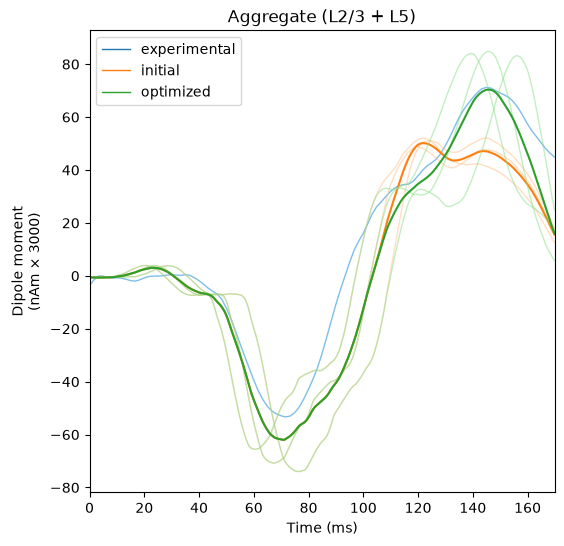

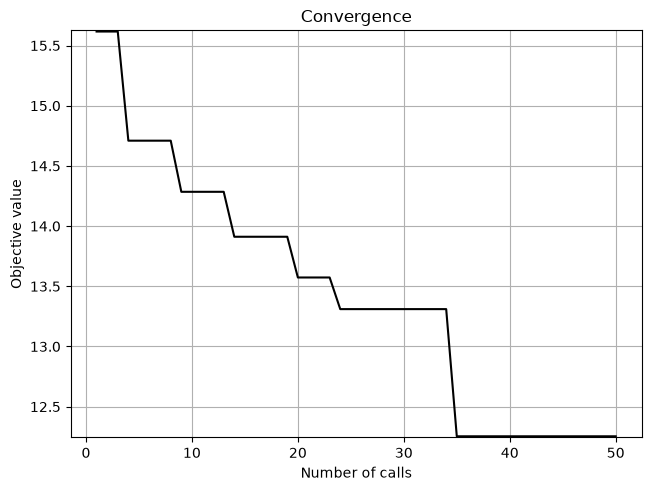

In [12]:
fig, ax = plt.subplots(sharex=True, figsize=(6, 6))
dipole_experimental.plot(ax=ax, layer='agg', show=False,
                         color='tab:blue')
plot_dipole(dipoles_initial.copy(), ax=ax, layer='agg', show=False,
            color='tab:orange', average=True)
plot_dipole(dipoles_optimized.copy(), ax=ax, layer='agg',
            show=False, color='tab:green', average=True)

# Legend
legend_handles = [Line2D([0], [0], color='tab:blue', lw=1.0),
                  Line2D([0], [0], color='tab:orange', lw=1.0),
                  Line2D([0], [0], color='tab:green', lw=1.0)]
ax.legend(legend_handles, ['experimental', 'initial', 'optimized'])

# Convergence plot
optim.plot_convergence()
plt.show()